# ◉ Multilayer perceptron (MLP)

## n-gram model
We built a [character-level bigram](https://n03an.me/gpt/01_Bigram.html) model trained on a dataset of 32,000 names. Lets build a n-gram model using similar appraoch where n=4 i.e. 4-gram model.

### Shape of Input, Output and Weights
instead of single-character context, we will use 3-character sequence as input context and the next character as output. 

For the word "cat", the padded sequence is [".", "c", "a", "t", "."]. The 4-gram contexts and targets become:
* ["c", "a", "t"] → "."

* [".", "c", "a"] → "t"

... 😤 some grunt work...

In [20]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [21]:
# Build stoi and itos

chars = sorted(list(set(''.join(words))))
# s (str) to i (index)
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
# rever the array
itos = {i:s for s,i in stoi.items()}

print(f"stoi['a'] = {stoi['a']}")
print(f"itos[1] = {itos[1]}")

stoi['a'] = 1
itos[1] = a


#### Input
In case of bigram character model, we used the index of character in the vocabulary as input. In case of 4-gram model, we will need to convert the sequence of 3 characters into a single distinct integer.

i.e. There are **19,683 unique contexts** i.e. $27^3 = 19,683$.

Converting the 3-character context into a single integer is done by treating the 3 characters as a base-27 number.

$$
\boxed{
\text{ID} = \text{index}(c_0) \cdot 27^2 + \text{index}(c_1) \cdot 27 + \text{index}(c_2)
}
$$

where $c_0$, $c_1$, and $c_2$ are the three characters in the context. The index of each character is its position in the vocabulary (of size 27), including a special padding character (".") at index 0.



In [22]:
# 1. Create the dataset: map 3-character sequences to unique IDs
xs, ys = [], []
for w in ["emma"]:
    chs = ['.'] + list(w) + ['.']
    for i in range(len(chs) - 3):
        print(f'----sample {i+1} ----------------------')
        context = chs[i:i+3]  # 3-character window
        print(f'input sequence: {context}')
        target = chs[i+3]
        print(f'expected output: {target}')
        # Convert context to a unique integer (0 to 27³-1)
        ix_context = stoi[context[0]] * 27**2 + stoi[context[1]] * 27 + stoi[context[2]]
        print(f'unique number for {context} sequence: {ix_context}')
        ix_target = stoi[target]
        xs.append(ix_context)
        ys.append(ix_target)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of samples in "emma":', num)

----sample 1 ----------------------
input sequence: ['.', 'e', 'm']
expected output: m
unique number for ['.', 'e', 'm'] sequence: 148
----sample 2 ----------------------
input sequence: ['e', 'm', 'm']
expected output: a
unique number for ['e', 'm', 'm'] sequence: 4009
----sample 3 ----------------------
input sequence: ['m', 'm', 'a']
expected output: .
unique number for ['m', 'm', 'a'] sequence: 9829
number of samples in "emma": 3


- The first character (context[0]) is the most significant digit, so it's multiplied by 27 squared (27^2). 
- The second character (context[1]) is multiplied by 27^1
- The third character (context[2]) is multiplied by 27^0, which is 1. 
Adding these products together gives a unique integer for every unique combination of the three characters. This ensures every possible 3-character combination gets a **unique integer ID** between 0 and \(27^3 - 1 = 19,682\).

> For example, if the characters are 'a', 'b', 'c' with indices 1, 2, 3 respectively, the calculation would be $$1 \cdot 27^2 + 2 \cdot 27^1 + 3 \cdot 1 = 729 + 54 + 3 = 786$$

**One-hot encoding**: with the total sequence size of 19683, the input to the model will be a one-hot vector of size Nx19683, where N is the batch size from the dataset. From our 32k names dataset, we can fetch total of 164080 3-char name sequences...

```python
xenc = F.one_hot(xs, num_classes=27**3).float()  # Shape [164080, 19683]
```
Note: each entry in `xs` represents a unique hash value for a 3-character sequence. The maxium value possible is 19682 for something like "zzz" and minimum is 0 for something like "...". So if the one hot vector row is representing `4009` for `emm` then  the 4009th index will be set to 1 and rest will be 0.


**Output**: The output will be a probability distribution of size 27 for each input in the batch of size N.

**Weights**: The weights will be a matrix of size (19683, 27). This means that each unique combination of 3 characters (row) will have a corresponding weight vector (27 columns) for each character in the vocabulary. (this is similar to how we were maintaining counts of character pairs in the bigram model).

```python
W = torch.randn((27**3, 27), generator=g, requires_grad=True)  # Shape [19683, 27]
```

In [23]:

xenc = F.one_hot(xs, num_classes=27**3).float()
print(f'input samples "xs" from emma : {xs}')
print('Shape of One Hot vector [Samples x Vocab Size]:', xenc.shape)
print(f'One hot vector for the first sample {xs[0]}:', xenc[0])

input samples "xs" from emma : tensor([ 148, 4009, 9829])
Shape of One Hot vector [Samples x Vocab Size]: torch.Size([3, 19683])
One hot vector for the first sample 148: tensor([0., 0., 0.,  ..., 0., 0., 0.])


basically the bit at position 148 would be 1, where rest 19682 entries would be 0

**Representing one hot encoding with 19683 into 3D - just for fun**

Sequence Indices: [  290 11845  3755  1715 14571 19312 13289  8062 16550 11901]
One-Hot Shape: (10, 19683)


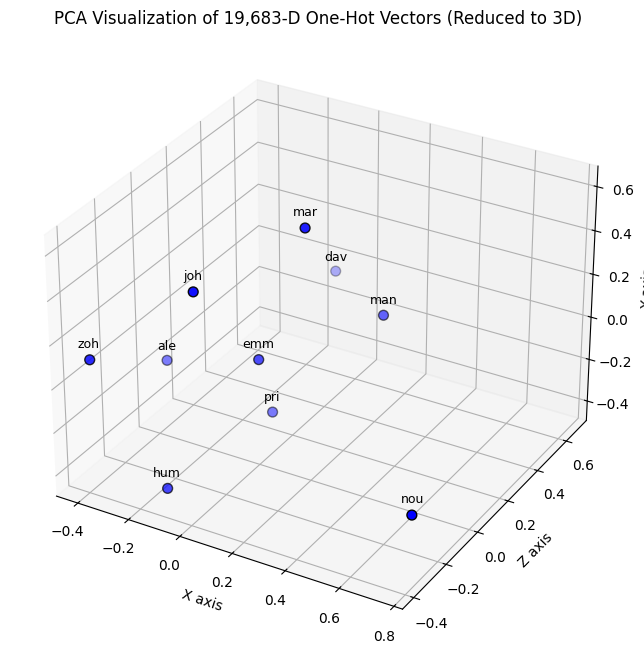

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.utils import to_categorical
from mpl_toolkits.mplot3d import Axes3D  # Import 3D plotting toolkit


charseq = ['emm', 'joh', 'mar', 'zoh', 'pri', 'hum', 'dav', 'ale', 'nou', 'man']
# generate 10 random integers within 19683 for representational purpose
indices = np.random.randint(0, 19683, size=10)  # Replace with your actual data
print("Sequence Indices:", indices)

# One-hot encode the sequences (shape: 10 x 19683)
one_hot_vectors = to_categorical(indices, num_classes=19683)
print("One-Hot Shape:", one_hot_vectors.shape)  # Output: (10, 19683)

# Reduce dimensionality to 3D using PCA
pca = PCA(n_components=3)
reduced_vectors = pca.fit_transform(one_hot_vectors)

# Create 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter points in 3D
scatter = ax.scatter(
    reduced_vectors[:, 0],  # PCA Component 1 (X-axis)
    reduced_vectors[:, 1],  # PCA Component 2 (Y-axis)
    reduced_vectors[:, 2],  # PCA Component 3 (Z-axis)
    c='blue', 
    edgecolor='k',
    s=50  # Marker size
)

# Annotate points with their original indices
for i, idx in enumerate(charseq):
    ax.text(
        reduced_vectors[i, 0], 
        reduced_vectors[i, 1], 
        reduced_vectors[i, 2] + 0.1, 
        str(idx), 
        fontsize=9,
        ha='center', 
        va='top'
    )

# Add labels and title
ax.set_title("PCA Visualization of 19,683-D One-Hot Vectors (Reduced to 3D)")
ax.set_xlabel("X axis")
ax.set_ylabel("Z axis")
ax.set_zlabel("Y axis")

plt.show()

#### Training the 4-gram model on 32k names dataset

In [25]:
import time

xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for i in range(len(chs) - 3):
        context = chs[i:i+3]  
        target = chs[i+3]
        ix_context = stoi[context[0]] * 27**2 + stoi[context[1]] * 27 + stoi[context[2]]
        ix_target = stoi[target]
        xs.append(ix_context)
        ys.append(ix_target)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(xs.unique().shape)
print('number of samples in extracted from names dataset :', num)

# 2. Initialize weights for 19,683 possible contexts
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27**3, 27), generator=g, requires_grad=True)  # Shape [19683, 27]

def train(n, iteration):
    for k in range(n):
        start_time = time.time()
        # forward pass
        xenc = F.one_hot(xs, num_classes=27**3).float()  # Shape [164080, 19683]
        logits = xenc @ W  # Shape [164080, 27]
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)
        loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
        
        # Backward pass and update
        W.grad = None
        loss.backward()

        # Update weights
        W.data += -50 * W.grad

        end_time = time.time()
        print(f'iteration {k+1} took {end_time - start_time:.2f} seconds')
    
    print(f'loss = {loss.item()} after training set {iteration}')

# Too slow
train(10, 1)
# train(100, 2)
# train(100, 3)
# train(100, 4)
# train(100, 5)

torch.Size([5659])
number of samples in extracted from names dataset : 164080
iteration 1 took 15.66 seconds
iteration 2 took 15.82 seconds
iteration 3 took 14.59 seconds
iteration 4 took 13.86 seconds
iteration 5 took 14.95 seconds
iteration 6 took 14.67 seconds
iteration 7 took 14.29 seconds
iteration 8 took 13.61 seconds
iteration 9 took 13.85 seconds
iteration 10 took 14.36 seconds
loss = 3.596501350402832 after training set 1


#### ⚠️ the model is very slow to train i.e. it took 2.5 minutes to train on a M4 Max macbook pro machine to perform 10 iterations

#### Generate Names

In [27]:
for i in range(10):
  
  out = []
  samples = 0
  while True:
    xenc = F.one_hot(torch.tensor([samples]), num_classes=27**3).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------
    
    samples = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[samples])
    if samples == 0:
      break
  print(''.join(out))

ozaltiygkbvmfhsy.
pbogmup.
rajqxedbvbuzwdbterdkriirejkmc.
pxjszwtognw.
phwmklecvogwptjw.
oqr.
trzikluuiqtgkpjluipalrh.
zsvwiisxlppohufpblvkhwdwmywpajwkkgkfuyu.
gdctktprqoafyypcccnabmunvloc.
fpjqbwrfbmalpbcjqxjmxc.


In [ ]:
print('Total number of samples from names dataset :', num)
print(f'Unique 3 character sequence: {xs.unique().nelement()}')
print(f'No of unique sequences model have not seen: {num - xs.unique().nelement()}')

Total number of samples from names dataset : 164080
Unique 3 character sequence: 5659
No of unique sequences model have not seen: 158421


With a dataset of 32,000 names, we could barely generate 5659 unique sequence or tokens. Which means that the model have yet to learn on the remainder of 158421 possible sequences.

#### 🤷‍♂️ how is this better than bigram...
- The model seems very slow
- We could only produce 5659 unique names from 32k names dataset
- the output is as rubbish as the bigram model

**Challenges**

1. **Sparsity and Memory Overhead**:
   - **One-Hot Encoding**: We can think of the 19,683 3-character sequences as **categorical features** — or one-hot encoded where each sample is a **sparse vector with 19,683 dimensions** (only one element is `1`, the rest are `0`). Storing 164,080 sparse vectors in memory as dense arrays is highly inefficient for what we are trying to achieve.
   - **Weight Matrix**: The weight matrix `(19683x27)` contains $(19683 \times 27 = 531,441)$ parameters. Thats again huge for tiny model.

2. **Generalization**:
   - **Rare 3-gram Sequences**: Many of the 19,683 possible 3-character sequences will appear infrequently (or not at all) in the training data. The model will fail to learn meaningful patterns for rare sequences, leading to poor generalization. In our case we could only generate 5659 unique names from 32k names dataset.

3. **Computational Cost**:
   - Matrix operations on large one-hot encoded inputs (e.g., multiplying `164080x19683` with `19683x27`) are computationally expensive.

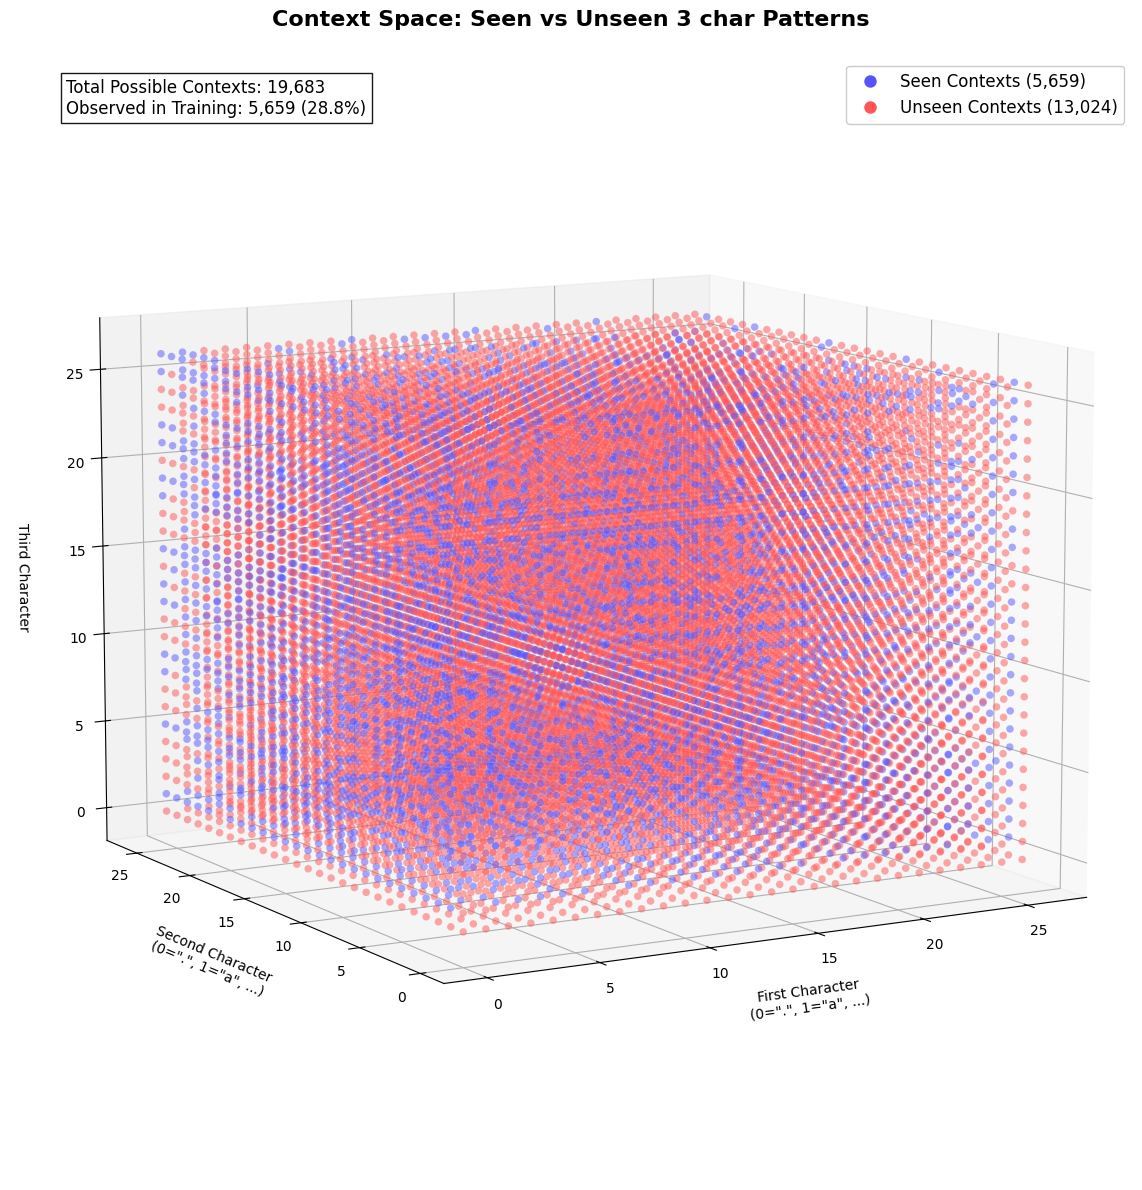

In [62]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
import torch

# Get seen contexts from training data
seen_contexts = torch.unique(xs)
all_contexts = torch.arange(27**3)
is_seen = torch.isin(all_contexts, seen_contexts)

# Convert indices to 3D coordinates
def index_to_3d(idx):
    c1 = idx // (27*27)
    idx = idx % (27*27)
    c2 = idx // 27
    c3 = idx % 27
    return c1, c2, c3

# Create coordinate arrays
c1, c2, c3 = zip(*[index_to_3d(i) for i in range(27**3)])

# Create figure
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection='3d')

# Custom colormap: Red (unseen), Blue (seen)
cmap = ListedColormap(['#ff5555', '#5555ff'])  # Bright colors

# Plot all contexts with color indicating seen/unseen
scatter = ax.scatter(
    c1, c2, c3,
    c=is_seen.numpy(),          # 0=unseen (red), 1=seen (blue)
    cmap=cmap,
    alpha=0.5,                  # Semi-transparent
    s=30,                       # Larger points
    edgecolor='w',              # White edges for contrast
    linewidth=0.1,
    depthshade=False            # Disable depth shading for clarity
)

# Create custom legend
seen_proxy = plt.Line2D([0], [0], linestyle='none', 
                      marker='o', markersize=10,
                      markerfacecolor='#5555ff',
                      markeredgecolor='w',
                      label='Seen Contexts (5,659)')

unseen_proxy = plt.Line2D([0], [0], linestyle='none', 
                        marker='o', markersize=10,
                        markerfacecolor='#ff5555',
                        markeredgecolor='w',
                        label='Unseen Contexts (13,024)')

ax.legend(handles=[seen_proxy, unseen_proxy], 
        loc='upper right',
        fontsize=12,
        framealpha=1)

# Axis labels with adjusted positioning
ax.set_xlabel('First Character\n(0=".", 1="a", ...)', 
            fontsize=10, labelpad=15)
ax.set_ylabel('Second Character\n(0=".", 1="a", ...)', 
            fontsize=10, labelpad=15)
ax.set_zlabel('Third Character', 
            fontsize=10, labelpad=15)

# Adjust viewing angle and margins
ax.view_init(elev=10, azim=-120)  # Experiment with these values
ax.dist = 10  # Camera distance (default is 10)
plt.tight_layout(pad=3.0)  # Add padding around plot

# For Jupyter-like rotation in VS Code
ax.mouse_init(rotate_btn=1, zoom_btn=3)

# Set viewing angle
# ax.view_init(elev=25, azim=-45)

# Add grid and title
ax.grid(True, alpha=0.3)
plt.title('Context Space: Seen vs Unseen 3 char Patterns\n', 
        fontsize=16, fontweight='bold')

# Add annotation about data sparsity
ax.text2D(0.05, 0.95, 
        f"Total Possible Contexts: {27**3:,}\n"
        f"Observed in Training: {len(seen_contexts):,} ({len(seen_contexts)/27**3:.1%})",
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()

## The Curse of Dimensionality [🚧 WIP]
🚧 TODO 🐫🔍 Study and implement the paper from Bengio
The paper by Bengio et al. (2003), "[*A Neural Probabilistic Language Model*](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)"

A goal of statistical language modeling is to learn the joint probability function of sequences of words _[or characters or tokens]_ in a language. This is difficult because a word sequence on which the model is trained may be very different from the word sequence on which the model is tested. This is called the _curse of dimensionality_. The curse of dimensionality refers to the fact that as the number of features (or dimensions) increases, the amount of data needed to estimate the joint probability function grows exponentially. This makes it difficult to learn a good model from limited data.


---

Given for such a large dimension / features of size 19,683 - most sequence will never appear in training data (making it sparse) and the model cannot generalize to unseen sequences (e.g., "xyz").

Language models predict the probability of the next word given previous words. For example:  
> *"The cat sat on the ___."*  
A model must predict "mat," "couch," etc.  

---

#### **The Problem**:  
- **Vocabulary size**: Suppose we have a vocabulary of 50,000 words.  
- **Sequence length**: If we model 10-word sequences, the number of possible combinations is \(50,000^{10}\)—a **high-dimensional discrete space**.  
- **Data sparsity**: Even with massive text corpora, most sequences will **never appear** in training data. For example, "*The purple refrigerator sang opera gracefully*" might never occur, making probability estimation impossible.  

This is the curse of dimensionality: the **exponential growth** of possible combinations in high-dimensional spaces makes learning statistically infeasible.

---

### **Example from the Paper**:  

1. **Learning distributed representations**:  
   - Instead of treating words as discrete "one-hot" vectors (e.g., 50,000 dimensions), words are mapped to **lower-dimensional embeddings** (e.g., 100-D).  
   - *Example*: Words like "cat" and "dog" have similar embeddings, capturing semantic relationships.  

2. **Sharing statistical strength**:  
   - Similar words share parameters in the embedding space. For example, if "*cat*" and "*kitten*" have similar embeddings, the model can generalize from "*The cat sat*" to "*The kitten sat*" without needing to see both phrases.  

3. **Avoiding exponential reliance on history**:  
   - Traditional n-gram models suffer because they explicitly model \(P(\text{word}_t | \text{word}_{t-1}, \dots, \text{word}_{t-n})\). For \(n=5\), this requires estimating probabilities for \(50,000^5\) combinations.  
   - Neural networks instead **compress** this information into dense vectors and nonlinear transformations, reducing dimensionality.

## Implementing the network from Bengio's paper

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [38]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [39]:
len(words)

32033

build the vocabulary of characters and mappings to/from integers

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


Building the dataset (starting with 3 names) with the context of 3 characters and the next character as target.

In [ ]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:3]:
  
  print('START-------------',w)
  context = [0] * block_size  # initially all 0s i.e. [0, 0, 0]
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop the last char and append ix e.g. [0, 0, 5] for `e` in emma
  print('-------------END')
  
X = torch.tensor(X)
Y = torch.tensor(Y)

START------------- emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
-------------END
START------------- olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
-------------END
START------------- ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
-------------END


In [42]:
# X (input) is a [number of examples, block size] matrix
# Y (output) is a [number of examples] vector
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([16, 3]), torch.int64, torch.Size([16]), torch.int64)

In [ ]:
# The objective is to embed 3 character sequence in 2-d space
# Initialising weight matrix - with 27 charactes in 2 dimensions
# The paper talks about embedding 17K words in 30 dimensional space
C = torch.randn((27, 2))

In [44]:
C[5]

tensor([0.3290, 1.5268])

In [45]:
F.one_hot(torch.tensor(5), num_classes=27).float() # one-hot encoding

tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

Multiplying One hot by C would lead us to the same results as indexing C with the respective character index. In below example only the index 5 would be 1 and all others would be 0. So the result of the multiplication would be the same as C[5] (rest of the rows are zero and would be masked out)

In [46]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C 

tensor([0.3290, 1.5268])

#### Pytorch Indexing

In [96]:
# Pytorch indexing for list and tensors
print(C[[5, 5, 5, 2]]) #automagicallyy multiply even if you index same values
print(C[torch.tensor([5, 5, 5, 2])])
print(C[torch.tensor([5, 5, 5, 2])].shape)
print(C[X[1]].shape) # each character have 2 values in C, so a sequence of 2 will give 3x2 matrix
print(C[X].shape) #expands the shape on how you index [samples, block size, dimentions]

tensor([[ 0.3290,  1.5268],
        [ 0.3290,  1.5268],
        [ 0.3290,  1.5268],
        [-0.2141, -1.4388]])
tensor([[ 0.3290,  1.5268],
        [ 0.3290,  1.5268],
        [ 0.3290,  1.5268],
        [-0.2141, -1.4388]])
torch.Size([4, 2])
torch.Size([3, 2])
torch.Size([16, 3, 2])


In [72]:
X[1].tolist()[1] # convert to list

0

##### Here is the network from the paper

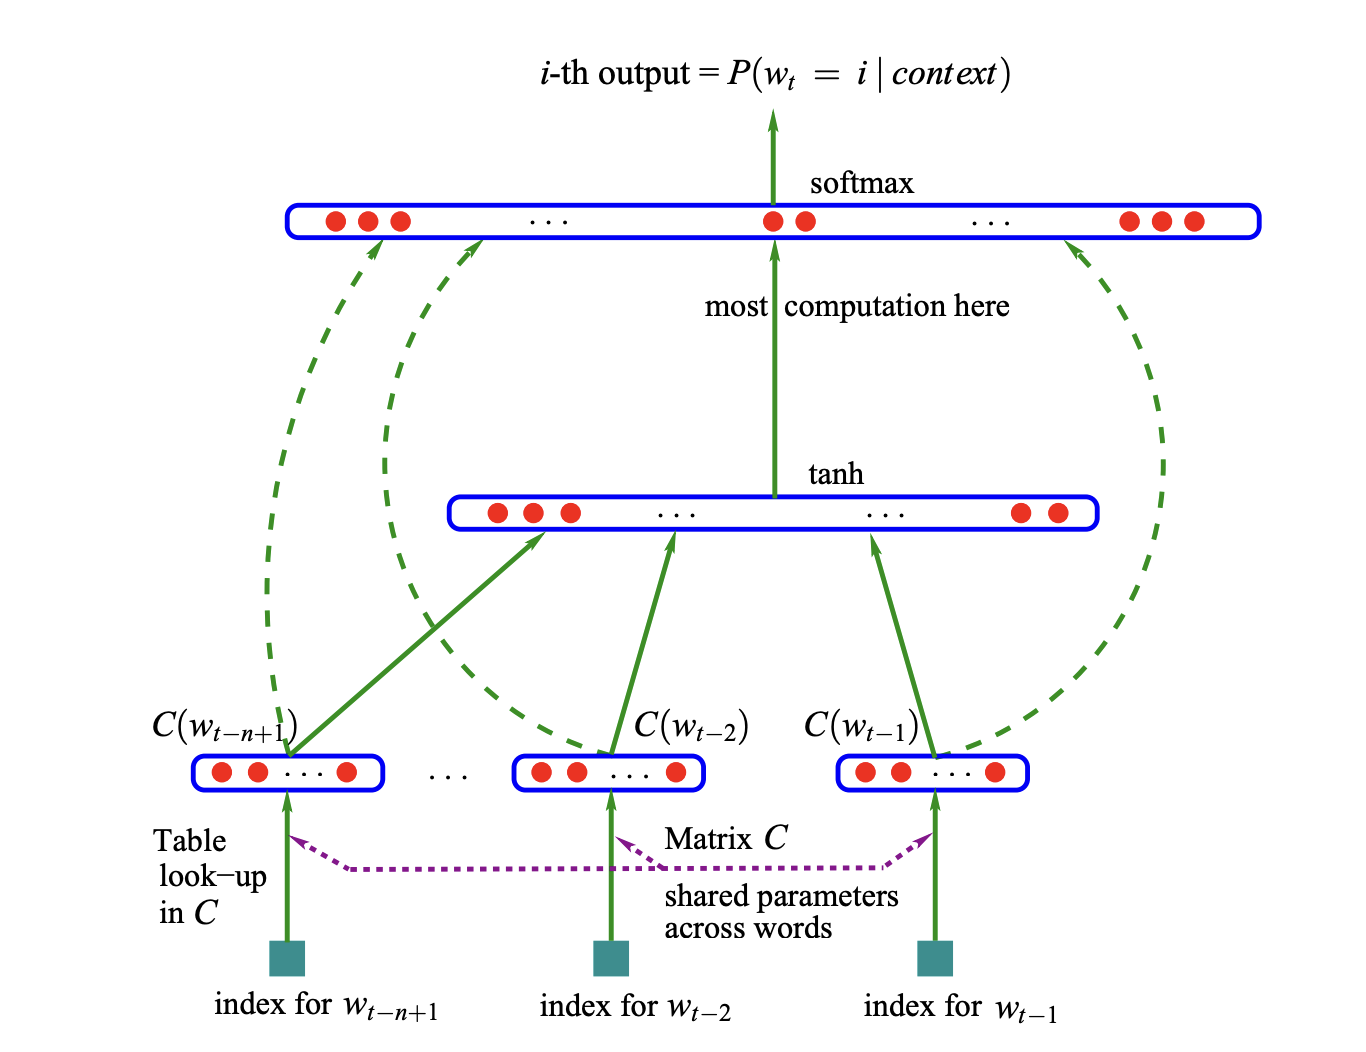

Creating the first input layer - embedding

In [ ]:
emb = C[X]
print('shape of embedding:', emb.shape)
print('===============')
for i in range(5):
    items = X[i].tolist()
    print(f'sample {i+1}:', items, '==>', itos[items[0]], itos[items[1]], itos[items[2]])
    print(f'embedding for sample {i+1}: \n', emb[i])
    print('===============')

# embedding size is [number of examples, block size, dimention size]


shape of embedding: torch.Size([16, 3, 2])
sample 1: [0, 0, 0] ==> . . .
embedding for sample 1: 
 tensor([[ 0.1207, -0.0768],
        [ 0.1207, -0.0768],
        [ 0.1207, -0.0768]])
sample 2: [0, 0, 5] ==> . . e
embedding for sample 2: 
 tensor([[ 0.1207, -0.0768],
        [ 0.1207, -0.0768],
        [ 0.3290,  1.5268]])
sample 3: [0, 5, 13] ==> . e m
embedding for sample 3: 
 tensor([[ 0.1207, -0.0768],
        [ 0.3290,  1.5268],
        [ 0.1442, -0.1842]])
sample 4: [5, 13, 13] ==> e m m
embedding for sample 4: 
 tensor([[ 0.3290,  1.5268],
        [ 0.1442, -0.1842],
        [ 0.1442, -0.1842]])
sample 5: [13, 13, 1] ==> m m a
embedding for sample 5: 
 tensor([[ 0.1442, -0.1842],
        [ 0.1442, -0.1842],
        [ 0.5165,  1.4791]])


We would basically want to do 
`embedding (input) @ Weights + Biases`
If we randomyly choose a weights matrix with 6 rows (3 x 2 since our block size is 3 and each character have 2 dimensions), we will not be able to multiple embeeding with weights because the shape of embedding is 3 dimentional tensor vs 2 dimensional tensor of weights. We need to reshape the embedding to 2D tensor. 

In [98]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [112]:
# Pluck the 2D for each character and then contact to convert 3x2 into 1x6
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape


torch.Size([16, 6])

The problem with above approach is that we are hardcoding the block size. When we change the bolck size from 3 to 5 then the code will break. Alternative way is to use `view` method of pytorch tensor.

In [118]:
eg = torch.arange(10)
print(eg)
print(eg.view(2, 5))

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])


In [121]:
# We can acrive to the same result
emb.view(-1, 6).shape # -1 means infer the size

torch.Size([16, 6])

#### Creating the second layer - hidden layer tanh

In [122]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [123]:
h

tensor([[ 0.6414, -0.2580,  0.7209,  ...,  0.1903,  0.8674, -0.9533],
        [ 0.4587, -0.9905,  0.6372,  ..., -0.1977,  0.9836,  0.9674],
        [ 0.9974,  0.9324,  0.7589,  ..., -0.7985, -0.3427, -0.9389],
        ...,
        [ 0.3427, -0.9808,  0.8126,  ..., -0.0742,  0.9822,  0.9873],
        [ 0.9985, -0.4251,  0.4107,  ..., -0.9287,  0.3396, -0.5571],
        [ 0.9962,  0.6904,  0.9602,  ...,  0.6234,  0.9938,  0.9998]])

In [124]:
h.shape

torch.Size([16, 100])

In [125]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [126]:
logits = h @ W2 + b2

In [127]:
logits.shape

torch.Size([16, 27])

In [128]:
counts = logits.exp()

In [129]:
prob = counts / counts.sum(1, keepdims=True)

In [130]:
prob.shape

torch.Size([16, 27])

In [132]:
loss = -prob[torch.arange(16), Y].log().mean()
loss

tensor(16.3154)

**Put it all together for 3 words**

In [142]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:3]:
  
  print('START-------------',w)
  context = [0] * block_size  # initially all 0s i.e. [0, 0, 0]
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop the last char and append ix e.g. [0, 0, 5] for `e` in emma
  print('-------------END')
  
X = torch.tensor(X)
Y = torch.tensor(Y)
print(f'X [No of samples, context length]: {X.shape}')
print(f'Y [output labels]: {Y.shape}')

emb = C[X]
print('shape of embedding: [No of samples, context length, dimentions]: ', emb.shape)

# initialisation with 100 neurons
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
print('shape of W1 [context length x dimention, Arbitory no of Neurons]:', W1.shape)
print('shape of b1:', b1.shape)

h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
print('shape of h:', h.shape)

W2 = torch.randn((100, 27))
b2 = torch.randn(27)
print('shape of W2:', W2.shape)
print('shape of b2:', b2.shape)

logits = h @ W2 + b2
print('shape of logits:', logits.shape)
counts = logits.exp()
print('shape of counts:', counts.shape)
prob = counts / counts.sum(1, keepdims=True)
print('shape of prob:', prob.shape)
loss = -prob[torch.arange(16), Y].log().mean()
print('loss:', loss)



START------------- emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
-------------END
START------------- olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
-------------END
START------------- ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
-------------END
X [No of samples, context length]: torch.Size([16, 3])
Y [output labels]: torch.Size([16])
shape of embedding: [No of samples, context length, dimentions]:  torch.Size([16, 3, 2])
shape of W1 [context length x dimention, Arbitory no of Neurons]: torch.Size([6, 100])
shape of b1: torch.Size([100])
shape of h: torch.Size([16, 100])
shape of W2: torch.Size([100, 27])
shape of b2: torch.Size([27])
shape of logits: torch.Size([16, 27])
shape of counts: torch.Size([16, 27])
shape of prob: torch.Size([16, 27])
loss: tensor(13.3338)


Leveraging torch cross entropy loss function over manual computation of loss function. Because

- torch uses fused kernel instead of manually creating so many tensors (which is memory efficient)
- simplify the mathematical computation and derivatives

In [143]:
F.cross_entropy(logits, Y)

tensor(13.3338)

## MLP on 32k names dataset

### Vocabulary setup (27 characters: a-z + .)

In [2]:
chars = 'abcdefghijklmnopqrstuvwxyz.'
char_to_ix = {ch:i for i, ch in enumerate(chars)}
ix_to_char = {i:ch for i, ch in enumerate(chars)}
vocab_size = len(chars)

In [5]:
# build the dataset
words = open('names.txt', 'r').read().splitlines()
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = char_to_ix[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


### Hyperparameters

In [6]:
# Hyperparameters
embedding_dim = 50  # Dimension of character embeddings
hidden_dim = 100     # Hidden layer size 
learning_rate = 0.1
context_size = 3     # Number of previous characters to consider
minibatch_size = 32 # Number of samples in each minibatch
# Initialize parameters
g = torch.Generator().manual_seed(2147483647 + 10)

print('====================')
print('Hyperparameters:')
print('Context size:', context_size)
print('Embedding dim per character:', embedding_dim)
print('Hidden dim (arbitory):', hidden_dim)
print('Learning rate:', learning_rate)
print('Vocab size:', vocab_size)
print('Training mini-batch size:', minibatch_size)
print('====================')

# Embedding matrix (27 x embedding_dim per char)
C = torch.randn((vocab_size, embedding_dim), generator=g)
print('Embodding matrix (vocab_size x embedding_dim per char):', C.shape)
# Hidden layer weights ((context_size*embedding_dim) x hidden_dim)
W1 = torch.randn((context_size * embedding_dim, hidden_dim), generator=g)
print('Hidden layer weights ((context_size * embedding_dim) x hidden_dim):', W1.shape)
b1 = torch.randn(hidden_dim, generator=g)  # Hidden layer bias
print('Hidden layer bias (hidden dim):', b1.shape)
# Output layer weights (hidden_dim x vocab_size)
W2 = torch.randn((hidden_dim, vocab_size), generator=g)
print('Output layer weights (hidden_dim x vocab_size):', W2.shape)
b2 = torch.randn(vocab_size, generator=g) # Output layer bias
print('Output layer bias (vocab_size):', b2.shape)

parameters = [C, W1, b1, W2, b2]
total_parameters = sum(p.nelement() for p in parameters) # number of parameters in total
# Set requires_grad=True for all parameters
for p in parameters:
  p.requires_grad = True

print('Total number of parameters:', total_parameters)



Hyperparameters:
Context size: 3
Embedding dim per character: 50
Hidden dim (arbitory): 100
Learning rate: 0.1
Vocab size: 27
Training mini-batch size: 32
Embodding matrix (vocab_size x embedding_dim per char): torch.Size([27, 50])
Hidden layer weights ((context_size * embedding_dim) x hidden_dim): torch.Size([150, 100])
Hidden layer bias (hidden dim): torch.Size([100])
Output layer weights (hidden_dim x vocab_size): torch.Size([100, 27])
Output layer bias (vocab_size): torch.Size([27])
Total number of parameters: 19177


#### Forward Pass
1. Create a batch of indices from the training set
2. build the embedding tensor for the batch
3. Compute hidden layer activation (tanh)
4. Compute output scores (logits)
5. Compute probabilities using softmax
6. Compute loss using cross-entropy

In [7]:
def softmax(logits):
    counts = logits.exp()
    return counts / counts.sum(1, keepdims=True)

def cross_entropy_loss(probs, targets):
    # probs.shape[0] is the batch size
    return -probs[torch.arange(probs.shape[0]), targets].log().mean()

def forward(batch_size):
    # Randomly select a batch of indices from the training set
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    # Embedding lookup
    embeddings = C[Xtr[ix]]
    # Hidden layer
    h = torch.tanh(embeddings.view(-1, context_size * embedding_dim) @ W1 + b1)
    
    # Output layer (27 units)
    logits = h @ W2 + b2
    # probs = softmax(logits)
    # loss = cross_entropy_loss(probs, Ytr[ix])
    loss = F.cross_entropy(logits, Ytr[ix]) # recommended way to use torch instead of manually computing softmax and cross-entropy
    
    return loss

#### Backpropogation
* Reset the gradients of all parameters to zero.
* Compute the gradients of the loss with respect to each parameter and store them in the corresponding parameter's grad attribute.

In [8]:
def backward(loss):
    for p in parameters:
        p.grad = None
    
    loss.backward()

### learning rate schedule

* Early in training, large updates help the model learn quickly and escape poor local minima.
* Later in training, smaller updates help the model **converge more precisely** without overshooting or destabilizing.

We could also use torch linespace to create a learning rate schedule. This would be more efficient than manually creating the learning rate schedule. 

In [9]:
# exponential decay of learning rate 
lre = torch.linspace(-3, 0, 100)
lrs = 10**lre
lrs

tensor([0.0010, 0.0011, 0.0011, 0.0012, 0.0013, 0.0014, 0.0015, 0.0016, 0.0017,
        0.0019, 0.0020, 0.0022, 0.0023, 0.0025, 0.0027, 0.0028, 0.0031, 0.0033,
        0.0035, 0.0038, 0.0040, 0.0043, 0.0046, 0.0050, 0.0053, 0.0057, 0.0061,
        0.0066, 0.0071, 0.0076, 0.0081, 0.0087, 0.0093, 0.0100, 0.0107, 0.0115,
        0.0123, 0.0132, 0.0142, 0.0152, 0.0163, 0.0175, 0.0187, 0.0201, 0.0215,
        0.0231, 0.0248, 0.0266, 0.0285, 0.0305, 0.0327, 0.0351, 0.0376, 0.0404,
        0.0433, 0.0464, 0.0498, 0.0534, 0.0572, 0.0614, 0.0658, 0.0705, 0.0756,
        0.0811, 0.0870, 0.0933, 0.1000, 0.1072, 0.1150, 0.1233, 0.1322, 0.1417,
        0.1520, 0.1630, 0.1748, 0.1874, 0.2009, 0.2154, 0.2310, 0.2477, 0.2656,
        0.2848, 0.3054, 0.3275, 0.3511, 0.3765, 0.4037, 0.4329, 0.4642, 0.4977,
        0.5337, 0.5722, 0.6136, 0.6579, 0.7055, 0.7565, 0.8111, 0.8697, 0.9326,
        1.0000])

In [10]:
def update_parameters():
    lr = learning_rate if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

#### Training the network
* For each iteration, we sample a batch of data from the training set.
* We compute the forward pass, calculate the loss, and perform backpropagation to update the model parameters.
* We also keep track of the loss for each batch to monitor the training process.

In [11]:
# track learning stats
lossi = []
stepi = []

for i in range(200000):
    # forward pass
    loss = forward(minibatch_size)

    # Backward pass
    backward(loss)

    # update parameters
    update_parameters()

    # track stats
    stepi.append(i)
    lossi.append(loss.log10().item())

**Note**: This could further be improved by using epochs (more for capturing stats). 

- An epoch is one complete pass through the a training dataset (probably a subset).
- They give a data-centric view of training progress (e.g., "after 10 epochs...") instead of more fine grain iteration-centric view (e.g., "after 1000 iterations...")
- You often evaluate validation accuracy once per epoch
- Learning rate schedules or checkpoints are usually epoch-based
- Our above example can be refactored
    - we can divide 200,000 iterations into 60 small datasets (epochs)
    - Each epoch will roughly have 200,000 / 60 = 3333 iterations
    - Each iteration is a mini-batch of 32 samples

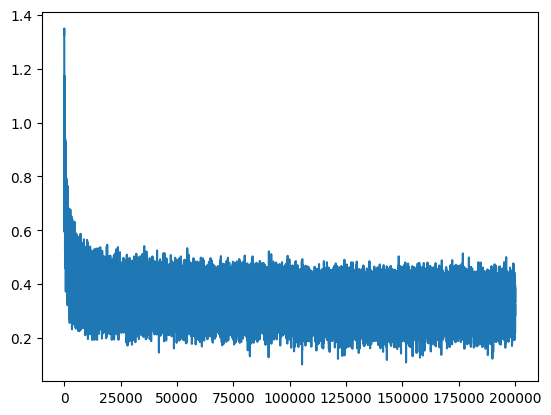

In [12]:
plt.plot(stepi, lossi)

Plotting just the first two dimension of the embedding layer

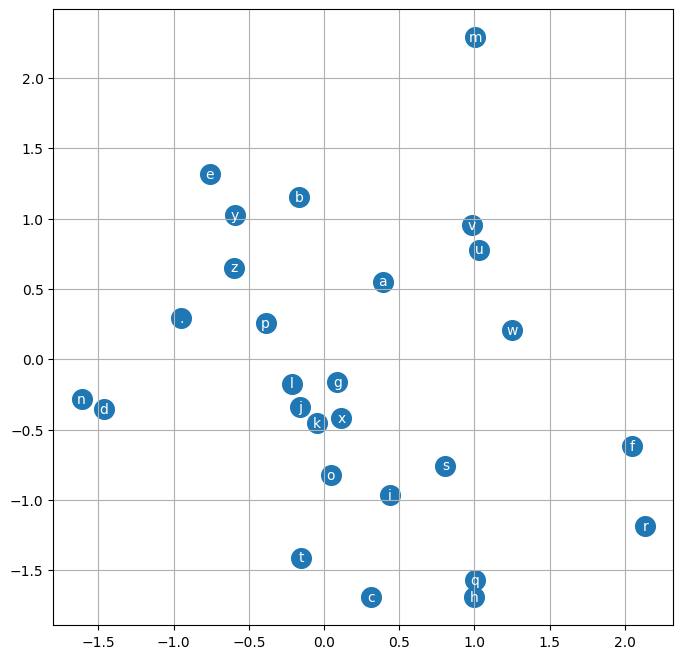

In [15]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

##### Loss
Calculating final loss on Training, Validation and Test set

In [19]:
def loss(X, Y):
    embeddings = C[X]
    h = torch.tanh(embeddings.view(-1, context_size * embedding_dim) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    return loss

print('Loss on training set:', loss(Xtr, Ytr).item())
print('Loss on dev set:', loss(Xdev, Ydev).item())
print('Loss on test set:', loss(Xte, Yte).item())

Loss on training set: 2.149606227874756
Loss on dev set: 2.2011258602142334
Loss on test set: 2.196885347366333


#### Generating Names
Sampling from the model

In [323]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amilll.
khi.
mili.
thal.
skaad.
kenleine.
fareslit.
kaeli.
nellana.
chaiivon.
leigh.
ham.
jord.
quint.
sulie.
alianni.
wavero.
dearynix.
kaekhiruan.


### Thoughts??
- The generated names are more name like than the bigram model.
- We did improve on our loss in comparison to the bigram model.